# Real-hardware run on `ibm_basquecountry` — any qubit count

Inference of the simulation-trained chain QNN on the real QPU, with TREX
readout mitigation + XY4 dynamical decoupling + Pauli twirling.

**Set `N_QUBITS` to 2, 4, 8 or 10** — the matching pack file
`hw_pack_top{N}q.npz` must be in the same folder. Each pack is
self-contained: trained weights + 1,000 pre-encoded test materials + target
scaling. Simulator reference (noiseless RMSE, our runs):

| N qubits | RMSE (K) | MAE (K) | R² | trainable params |
|---|---|---|---|---|
| 2 | 21.69 | 15.55 | 0.571 | 14 |
| 4 | 20.15 | 14.72 | 0.630 | 26 |
| 8 | 17.30 | 12.91 | 0.727 | 50 |
| 10 | 16.90 | 12.58 | 0.740 | 62 |

Fill in your token and instance CRN in the config cell. Run cells one by
one — the job is only submitted in §5, so you can inspect the transpiled
circuit and today's calibration first.

In [ ]:
# %pip install qiskit qiskit-ibm-runtime numpy matplotlib
import json
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

# ============== FILL THESE IN ==============
IBM_TOKEN = "<PASTE_YOUR_TOKEN>"
IBM_CRN   = "<PASTE_YOUR_CRN>"
# ===========================================

BACKEND_NAME = "ibm_fez"
VERSION      = "top"     # "top" (feature selection) or "pca"
N_QUBITS     = 8         # 2, 4, 8 or 10
N_LAYERS     = 3         # 2 or 3 - must match a saved pack
N_MATERIALS  = 50
SHOTS        = 4096

import os
fname = f"hw_pack_{VERSION}_{N_QUBITS}q_{N_LAYERS}L.npz"
if not os.path.exists(fname) and VERSION == "top" and N_LAYERS == 3:
    fname = f"hw_pack_top{N_QUBITS}q.npz"     # legacy pack name
pack = np.load(fname)
assert int(pack["N_QUBITS"]) == N_QUBITS and int(pack["N_LAYERS"]) == N_LAYERS
X_all, y_all = pack["X"], pack["y_true"]
y_mu, y_sd = float(pack["y_mu"]), float(pack["y_sd"])
w, w_out, b_out = pack["w"], float(pack["w_out"]), float(pack["b_out"])
X, y_true = X_all[:N_MATERIALS], y_all[:N_MATERIALS]
print(f"loaded {fname}: {VERSION}-{N_QUBITS}q-{N_LAYERS}L, "
      f"{len(w)} weights, using {len(X)}/{len(X_all)} materials")

loaded hw_pack_top8q.npz: top-8q-3L, 48 weights, using 50/1000 materials


## §1. Circuit + observable (identical to the submission notebook)

In [5]:
def build_circuit(n=N_QUBITS, L=N_LAYERS):
    """Data re-uploading chain QNN (heavy-hex-native brickwork)."""
    x = ParameterVector("x", n)
    w_ = ParameterVector("w", 2*n*L)
    qc = QuantumCircuit(n); k = 0
    for _ in range(L):
        for i in range(n): qc.ry(np.pi/2*x[i], i)      # encoding
        for i in range(n):
            qc.ry(w_[k], i); k += 1                     # trainable
            qc.rz(w_[k], i); k += 1
        for i in range(0, n-1, 2): qc.cx(i, i+1)        # brickwork
        for i in range(1, n-1, 2): qc.cx(i, i+1)
    return qc

def observable(n=N_QUBITS):
    return SparsePauliOp.from_sparse_list(
        [("Z", [i], 1.0/n) for i in range(n)], num_qubits=n)

qc = build_circuit()
print(f"logical: depth {qc.depth()}, ops {dict(qc.count_ops())}")

logical: depth 15, ops {'ry': 48, 'rz': 24, 'cx': 21}


## §2. Connect to IBM Quantum and inspect today's calibration

In [6]:
assert "<PASTE" not in IBM_TOKEN and "<PASTE" not in IBM_CRN, \
    "Fill in IBM_TOKEN and IBM_CRN in the config cell."
try:
    service = QiskitRuntimeService()          # account already saved?
except Exception:
    QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
                                      token=IBM_TOKEN, instance=IBM_CRN,
                                      overwrite=True)
    service = QiskitRuntimeService()
backend = service.backend(BACKEND_NAME)
print(f"backend: {backend.name} | {backend.num_qubits} qubits")
print("native gates:", backend.target.operation_names)
try:
    errs = [backend.target["ecr"][q].error for q in backend.target["ecr"]
            if backend.target["ecr"][q] is not None]
    print(f"median ECR error today: {np.median(errs):.4f} "
          f"(best {min(errs):.4f}, worst {max(errs):.4f})")
except Exception as e:
    print("(could not read ECR calibration:", e, ")")

qiskit_runtime_service.__init__:WARNING:2026-07-12 13:02:37,760: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: Quantum-Hackathon-Cern. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-12 13:02:37,761: Using instance: Quantum-Hackathon-Cern, plan: premium


backend: ibm_fez | 156 qubits
native gates: dict_keys(['cz', 'id', 'delay', 'rz', 'if_else', 'sx', 'measure', 'reset', 'x'])
(could not read ECR calibration: 'ecr' )


## §3. Transpile to the real device — CHECK BEFORE SUBMITTING
Expect 2q gate count ≈ logical CX count (1:1, zero routing). If you see much
more, try another `seed_transpiler` before spending shots.

In [7]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend,
                                  seed_transpiler=11)
isa = pm.run(qc)
isa_obs = observable().apply_layout(isa.layout)
ops = isa.count_ops()
n2q = sum(int(ops.get(g, 0)) for g in ("ecr", "cz", "cx"))
n2q_logical = qc.count_ops().get("cx", 0)
print(f"ISA circuit: depth {isa.depth()}, 2q gates {n2q} "
      f"(logical {n2q_logical}), ops {dict(ops)}")
print("physical qubits used:", sorted(isa.layout.final_index_layout())
      if isa.layout else "n/a")
if n2q > 1.4 * n2q_logical:
    print("WARNING: routing overhead detected — try a different seed_transpiler")

ISA circuit: depth 41, 2q gates 21 (logical 21), ops {'rz': 154, 'sx': 82, 'cz': 21}
physical qubits used: [123, 124, 125, 136, 140, 141, 142, 143]


## §4. Bind parameters (each material's angles + trained weights)

In [8]:
params = list(isa.parameters)
xcols = [i for i, p in enumerate(params) if p.name.startswith("x")]
wcols = [i for i, p in enumerate(params) if p.name.startswith("w")]
vals = np.empty((len(X), len(params)))
vals[:, xcols] = X
vals[:, wcols] = w
print(f"pub bindings: {vals.shape[0]} materials x {vals.shape[1]} parameters")

pub bindings: 50 materials x 56 parameters


## §5. Submit the job (TREX + XY4 DD + twirling)
One job: `N_MATERIALS` bindings × `SHOTS` shots. ZNE off by default (it hurts
shallow circuits — submission notebook §9); uncomment to compare.

In [9]:
est = Estimator(mode=backend)
est.options.default_shots = SHOTS
est.options.resilience_level = 1                      # TREX readout mitigation
est.options.dynamical_decoupling.enable = True
est.options.dynamical_decoupling.sequence_type = "XY4"
est.options.twirling.enable_gates = True
# est.options.resilience.zne_mitigation = True
# est.options.resilience.zne.noise_factors = (1, 3, 5)

job = est.run([(isa, isa_obs, vals)])
print("job id:", job.job_id())
print("status:", job.status())

job id: d99n8md2su3c739km85g
status: QUEUED


## §6. Results: hardware RMSE / MAE / R² vs simulator reference

In [10]:
REF = {}   # noiseless top-N/3L references from our runs:
if VERSION == "top" and N_LAYERS == 3:
    REF = {2: (21.69, 15.55, 0.571), 4: (20.15, 14.72, 0.630),
           8: (17.30, 12.91, 0.727), 10: (16.90, 12.58, 0.740)}

res = job.result()[0]        # blocks until the job finishes
ev = np.asarray(res.data.evs, float).reshape(-1)

pred = (w_out*ev + b_out)*y_sd + y_mu
err = pred - y_true
rmse = float(np.sqrt((err**2).mean()))
mae = float(np.abs(err).mean())
r2 = float(1 - (err**2).sum()/((y_true - y_true.mean())**2).sum())
print(f"===== {backend.name}, {N_QUBITS} qubits =====")
print(f"hardware : RMSE {rmse:.2f} K | MAE {mae:.2f} K | R2 {r2:.3f} "
      f"({len(X)} materials, {SHOTS} shots)")
if N_QUBITS in REF:
    print(f"simulator: RMSE {REF[N_QUBITS][0]:.2f} K | MAE {REF[N_QUBITS][1]:.2f} K "
          f"| R2 {REF[N_QUBITS][2]:.3f} (noiseless, 1000 materials)")

out = {"backend": backend.name, "n_qubits": N_QUBITS,
       "n_materials": int(len(X)), "shots": SHOTS,
       "rmse_K": rmse, "mae_K": mae, "r2": r2,
       "simulator_ref": REF.get(N_QUBITS),
       "isa_depth": int(isa.depth()), "isa_2q": int(n2q),
       "resilience_level": 1, "dd": "XY4", "twirling": True,
       "job_id": job.job_id(),
       "pred": pred.tolist(), "y_true": y_true.tolist()}
with open(f"results_ibm_basquecountry_{VERSION}_{N_QUBITS}q_{N_LAYERS}L.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"saved -> results_ibm_basquecountry_{VERSION}_{N_QUBITS}q_{N_LAYERS}L.json")

===== ibm_fez, 8 qubits =====
hardware : RMSE 16.64 K | MAE 11.74 K | R2 0.632 (50 materials, 4096 shots)
simulator: RMSE 17.30 K | MAE 12.91 K | R2 0.727 (noiseless, 1000 materials)
saved -> results_ibm_basquecountry_top_8q_3L.json


## §7. (Optional) prediction scatter for the report

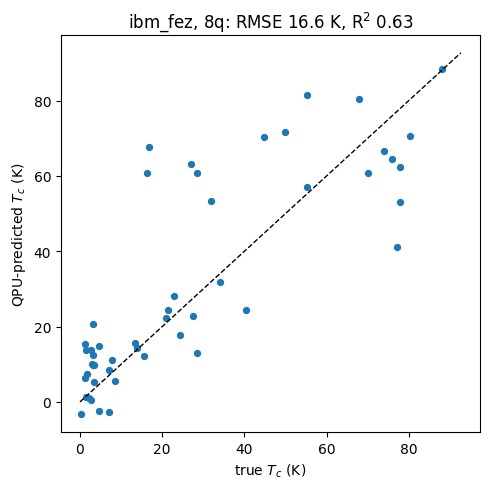

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.scatter(y_true, pred, s=18)
lim = [0, max(y_true.max(), pred.max())*1.05]
plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("true $T_c$ (K)"); plt.ylabel("QPU-predicted $T_c$ (K)")
plt.title(f"{backend.name}, {N_QUBITS}q: RMSE {rmse:.1f} K, R$^2$ {r2:.2f}")
plt.tight_layout()
plt.savefig(f"qpu_scatter_{N_QUBITS}q.png", dpi=150); plt.show()